# 自作 AI モデルの比較評価（my_ai）

`india-ai-model` で作成したスコアのうち、候補 3 本（初期ベースライン `ridge__baseline`、単体最良 `dnn_peer_na_cpr_s10`、
最終候補 `ens_lgbm_dnn`）と、それぞれの EMA 平滑化版（`_hl1`、半減期 1 か月）を `alphaeval` で評価する。
参照として合成スコア `composite/comp_ew`（Composite v1）も同じ条件で並べる。

india-ai-model 側の評価（rank IC、Q5−Q1、L/S 回転率）とは次の点が異なる。

| 項目 | india-ai-model | 本 Notebook（alphaeval） |
| --- | --- | --- |
| リターン | mart の `drtn_1m`（配当込み、営業日ベース） | `risk_models/GEMLT/return` の `rtn`（INR 建てトータルリターン、月次） |
| 主指標 | rank IC、Q5−Q1（ロング・ショート） | Q1（最上位 20%）のロングオンリー超過（対 MSCI India、対等ウェイト参照）、TE、IR、回転率、税控除後 |
| 分位の番号 | Q5 = 最上位 | **Q1 = 最上位**（`alphaeval` の規約） |
| ユニバース | MSCI India IMI | 同じ（`univ/`、スコアありの銘柄） |

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, evaluate_alpha, india_tax_schedule, performance_summary, portfolio_returns, quantile_analysis, weight_portfolio

pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})

# ---- パラメータ
INPUT_ROOT = "../../input/msci_india_imi"
SCORES = {
    "ridge_baseline": "my_ai/ridge__baseline",
    "ridge_baseline_hl1": "my_ai/ridge__baseline_hl1",
    "dnn_peer_na_cpr_s10": "my_ai/dnn_peer_na_cpr_s10",
    "dnn_peer_na_cpr_s10_hl1": "my_ai/dnn_peer_na_cpr_s10_hl1",
    "ens_lgbm_dnn": "my_ai/ens_lgbm_dnn",
    "ens_lgbm_dnn_hl1": "my_ai/ens_lgbm_dnn_hl1",
    "comp_ew (参照)": "composite/comp_ew",
}
CANDIDATES = ["ridge_baseline", "dnn_peer_na_cpr_s10", "ens_lgbm_dnn"]
BENCHMARK = "msci_india"
RISK_MODEL, RETURN_COL = "GEMLT", "rtn"
START, END = 201212, 202606            # スコアの期間（リターンは 1 か月先まで）
N_QUANTILES = 5
BUFFERS = (0.0, 0.1, 0.2)
COST_BUY, COST_SELL = 0.0015, 0.0025
FPI_TYPE = "trust"
BURN_IN = 12
IC_HORIZONS = (1, 3, 6, 12)

store = InputStore(INPUT_ROOT)

## 1. データ読み込みと一括評価

`evaluate_alpha` でカバレッジ・IC・分位（バッファ 0 / 0.1 / 0.2）・Q1 の税控除後評価をスコアごとに実行する。

In [2]:
univ = store.universe(START, END)
bm = store.benchmark(BENCHMARK, START, END)
rtn = store.returns(RISK_MODEL, RETURN_COL, START, 202607)
schedule = india_tax_schedule(FPI_TYPE)
scores = {k: store.alpha(v, START, END) for k, v in SCORES.items()}
bm_ret = portfolio_returns(bm, rtn)

results = {}
for name, score in scores.items():
    results[name] = evaluate_alpha(
        score, univ, rtn, bm, n_quantiles=N_QUANTILES, buffers=BUFFERS, scheme="equal",
        ic_horizons=IC_HORIZONS, tax_schedule=schedule, tax_quantiles=(1,),
        cost_buy=COST_BUY, cost_sell=COST_SELL, burn_in=BURN_IN,
    )
    print(f"{name:26s} done")

print("カバレッジ（ユニバース対比、銘柄数ベース平均）")
display(pd.DataFrame({k: r.coverage_summary for k, r in results.items()}).loc[["n_universe_mean", "n_covered_mean", "coverage_mean", "coverage_min", "weight_coverage_mean"]].astype(float).round(3))

ridge_baseline             done


ridge_baseline_hl1         done


dnn_peer_na_cpr_s10        done


dnn_peer_na_cpr_s10_hl1    done


ens_lgbm_dnn               done


ens_lgbm_dnn_hl1           done


comp_ew (参照)               done
カバレッジ（ユニバース対比、銘柄数ベース平均）


,ridge_baseline,ridge_baseline_hl1,dnn_peer_na_cpr_s10,dnn_peer_na_cpr_s10_hl1,ens_lgbm_dnn,ens_lgbm_dnn_hl1,comp_ew (参照)
n_universe_mean,399.098,399.098,399.098,399.098,399.098,399.098,399.098
n_covered_mean,399.098,399.098,399.098,399.098,399.098,399.098,399.074
coverage_mean,1.000,1.000,1.000,1.000,1.000,1.000,1.000
coverage_min,1.000,1.000,1.000,1.000,1.000,1.000,0.997
weight_coverage_mean,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 2. IC

Spearman IC（スコア高 = 翌期リターン高、ユニバース内）。ホライズン 1 / 3 / 6 / 12 か月。
india-ai-model 側の rank IC（1 か月 0.069 / 0.078 / 0.082）とおおむね一致するはず（リターンの定義差分だけずれる）。

,IC 1m,ICIR 1m,t 1m,勝率 1m,IC 3m,IC 6m,IC 12m,自己相関,n
ridge_baseline,0.066,0.444,5.670,0.693,0.079,0.077,0.046,0.079,163.0
ridge_baseline_hl1,0.062,0.408,5.204,0.675,0.073,0.070,0.041,0.089,163.0
dnn_peer_na_cpr_s10,0.074,0.554,7.074,0.761,0.087,0.090,0.054,0.057,163.0
dnn_peer_na_cpr_s10_hl1,0.071,0.498,6.364,0.724,0.084,0.086,0.050,0.059,163.0
ens_lgbm_dnn,0.078,0.551,7.038,0.718,0.093,0.095,0.056,0.066,163.0
ens_lgbm_dnn_hl1,0.074,0.497,6.340,0.675,0.089,0.089,0.051,0.054,163.0
comp_ew (参照),0.056,0.490,6.253,0.656,0.083,0.092,0.074,0.080,163.0


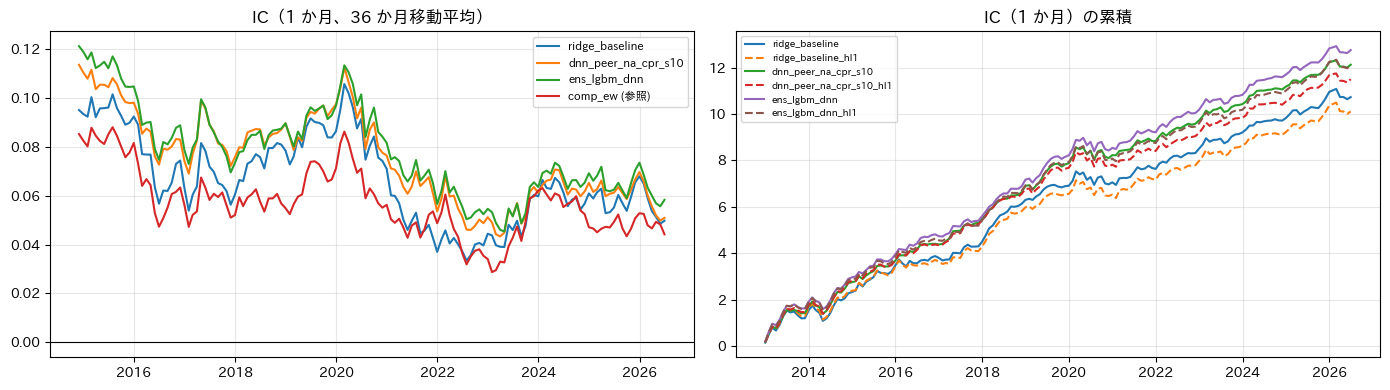

年別 IC（1 か月）


,ridge_baseline,dnn_peer_na_cpr_s10,ens_lgbm_dnn,comp_ew (参照)
2012,0.163,0.162,0.193,0.135
2013,0.115,0.130,0.144,0.096
2014,0.066,0.086,0.088,0.064
2015,0.096,0.078,0.082,0.084
2016,0.027,0.058,0.065,0.020
2017,0.058,0.091,0.072,0.052
2018,0.150,0.119,0.131,0.092
2019,0.051,0.081,0.087,0.069
2020,0.012,0.029,0.027,0.007
2021,0.048,0.051,0.056,0.070


In [3]:
rows = {}
for name, r in results.items():
    s = r.ic_summary
    rows[name] = {
        "IC 1m": s.loc["mean", "1"], "ICIR 1m": s.loc["icir", "1"], "t 1m": s.loc["t_stat", "1"], "勝率 1m": s.loc["hit_rate", "1"],
        "IC 3m": s.loc["mean", "3"], "IC 6m": s.loc["mean", "6"], "IC 12m": s.loc["mean", "12"], "自己相関": s.loc["autocorr_1", "1"], "n": s.loc["n", "1"],
    }
ic_tbl = pd.DataFrame(rows).T
display(ic_tbl.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name in CANDIDATES + ["comp_ew (参照)"]:
    axes[0].plot(results[name].ic.index, results[name].ic["1"].rolling(36, min_periods=24).mean(), label=name)
axes[0].axhline(0, color="k", linewidth=0.8)
axes[0].set_title("IC（1 か月、36 か月移動平均）")
axes[0].legend(fontsize=8)
for name in CANDIDATES:
    axes[1].plot(results[name].ic.index, results[name].ic["1"].cumsum(), label=name)
    axes[1].plot(results[name + "_hl1"].ic.index, results[name + "_hl1"].ic["1"].cumsum(), linestyle="--", label=name + "_hl1")
axes[1].set_title("IC（1 か月）の累積")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

print("年別 IC（1 か月）")
display(pd.DataFrame({name: results[name].ic["1"].groupby(results[name].ic.index.year).mean() for name in CANDIDATES + ["comp_ew (参照)"]}).round(3))

## 3. 分位ポートフォリオ（等ウェイト、Q1 = 最上位 20%）

Q1〜Q5 の年率リターンの単調性と、Q1 の対ベンチマーク（MSCI India、時価総額）・対等ウェイト参照（スコアあり銘柄の等ウェイト）の超過。

In [4]:
def ew_reference(score: pd.DataFrame) -> pd.Series:
    member = score.where(univ.notna()).notna()
    return portfolio_returns(weight_portfolio(member), rtn)


rows, mono = {}, {}
for name, r in results.items():
    q = r.quantiles[0.0]
    labels = q.labels
    ret = q.returns.iloc[BURN_IN:]
    ref = ew_reference(scores[name]).reindex(ret.index)
    s_bm = performance_summary(ret["Q1"], bm_ret.reindex(ret.index), q.turnover["Q1"].reindex(ret.index))
    s_ew = performance_summary(ret["Q1"], ref)
    s_sp = performance_summary(ret["spread"])
    rows[name] = {
        "Q1 年率": s_bm["ann_return"], "Q1 超過(vs BM)": s_bm["active_return"], "TE(vs BM)": s_bm["tracking_error"], "IR(vs BM)": s_bm["information_ratio"],
        "Q1 超過(vs EW)": s_ew["active_return"], "TE(vs EW)": s_ew["tracking_error"], "IR(vs EW)": s_ew["information_ratio"],
        "Q1−Q5 年率": s_sp["ann_return"], "Q1−Q5 R/R": s_sp["return_risk"], "年率回転率": s_bm["turnover_annual"], "平均銘柄数": q.n_holdings["Q1"].mean(),
    }
    mono[name] = {lab: performance_summary(ret[lab])["ann_return"] for lab in labels}
q_tbl = pd.DataFrame(rows).T
display(q_tbl.round(3))
print("分位別の年率リターン（Q1 = 最上位）")
display(pd.DataFrame(mono).T.round(3))

,Q1 年率,Q1 超過(vs BM),TE(vs BM),IR(vs BM),Q1 超過(vs EW),TE(vs EW),IR(vs EW),Q1−Q5 年率,Q1−Q5 R/R,年率回転率,平均銘柄数
ridge_baseline,0.231,0.094,0.077,1.216,0.054,0.074,0.726,0.130,0.810,3.557,79.847
ridge_baseline_hl1,0.213,0.078,0.076,1.032,0.038,0.079,0.483,0.092,0.540,2.059,79.847
dnn_peer_na_cpr_s10,0.244,0.106,0.090,1.176,0.066,0.072,0.918,0.160,1.030,5.271,79.847
dnn_peer_na_cpr_s10_hl1,0.239,0.101,0.085,1.190,0.061,0.077,0.796,0.138,0.840,3.003,79.847
ens_lgbm_dnn,0.248,0.109,0.085,1.288,0.069,0.075,0.916,0.161,0.993,5.165,79.847
ens_lgbm_dnn_hl1,0.246,0.107,0.082,1.296,0.067,0.078,0.854,0.160,0.966,2.965,79.847
comp_ew (参照),0.271,0.132,0.114,1.157,0.092,0.059,1.546,0.177,1.347,4.049,79.834


分位別の年率リターン（Q1 = 最上位）


,Q1,Q2,Q3,Q4,Q5
ridge_baseline,0.231,0.207,0.161,0.140,0.050
ridge_baseline_hl1,0.213,0.203,0.171,0.132,0.067
dnn_peer_na_cpr_s10,0.244,0.212,0.164,0.135,0.037
dnn_peer_na_cpr_s10_hl1,0.239,0.196,0.164,0.140,0.050
ens_lgbm_dnn,0.248,0.200,0.172,0.134,0.037
ens_lgbm_dnn_hl1,0.246,0.183,0.170,0.156,0.035
comp_ew (参照),0.271,0.193,0.153,0.122,0.055


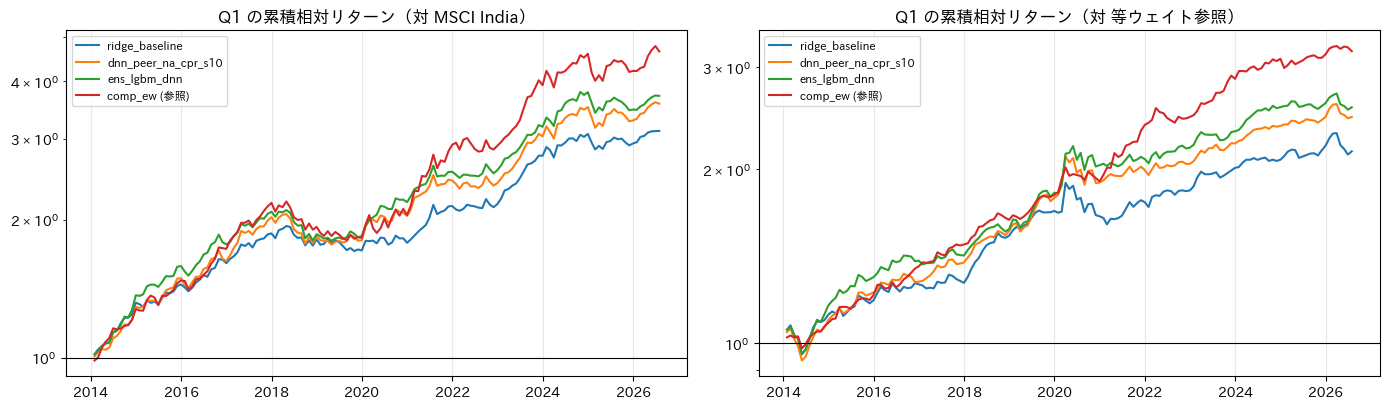

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for name in CANDIDATES + ["comp_ew (参照)"]:
    q1 = results[name].quantiles[0.0].returns["Q1"].iloc[BURN_IN:]
    ref = ew_reference(scores[name]).reindex(q1.index)
    axes[0].plot(q1.index, (1 + q1).cumprod() / (1 + bm_ret.reindex(q1.index)).cumprod(), label=name)
    axes[1].plot(q1.index, (1 + q1).cumprod() / (1 + ref).cumprod(), label=name)
for ax, t in zip(axes, ["Q1 の累積相対リターン（対 MSCI India）", "Q1 の累積相対リターン（対 等ウェイト参照）"]):
    ax.axhline(1, color="k", linewidth=0.8)
    ax.set_yscale("log")
    ax.set_title(t)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. 時価総額ウェイト版（キャパシティ）

Q1 を時価総額ウェイト（1 銘柄上限 5%）で保有した場合。等ウェイトとの差が大きいほど、効果が小型株に依存している。

In [6]:
rows = {}
for name, score in scores.items():
    q = quantile_analysis(score, rtn, univ, n_quantiles=N_QUANTILES, scheme="size", size=univ, max_weight=0.05)
    ret = q.returns["Q1"].iloc[BURN_IN:]
    s = performance_summary(ret, bm_ret.reindex(ret.index), q.turnover["Q1"].reindex(ret.index))
    rows[name] = {"Q1 CW 超過(vs BM)": s["active_return"], "TE": s["tracking_error"], "IR": s["information_ratio"], "年率回転率": s["turnover_annual"], "EW→CW の減衰": q_tbl.loc[name, "Q1 超過(vs BM)"] - s["active_return"]}
display(pd.DataFrame(rows).T.round(3))

,Q1 CW 超過(vs BM),TE,IR,年率回転率,EW→CW の減衰
ridge_baseline,0.053,0.060,0.889,2.974,0.040
ridge_baseline_hl1,0.040,0.061,0.664,1.598,0.038
dnn_peer_na_cpr_s10,0.064,0.067,0.957,5.390,0.042
dnn_peer_na_cpr_s10_hl1,0.052,0.068,0.761,2.920,0.050
ens_lgbm_dnn,0.054,0.066,0.821,5.057,0.055
ens_lgbm_dnn_hl1,0.053,0.066,0.794,2.844,0.054
comp_ew (参照),0.096,0.089,1.082,4.167,0.036


## 5. バッファと税控除後（Q1、等ウェイト）

バッファ付き分位（`docs/india_tcg.md` §3）で回転率を抑えた場合の、グロス / 売買コスト後 / 税控除後の超過リターン。
税は FIFO ロット台帳（信託扱い税率、INR 建てリターン）、売買コストは買い 15bp・売り 25bp。

年率回転率  超過 グロス(vs BM)  IR グロス  コストドラッグ  税ドラッグ   短期比率  超過 税後(vs BM)  IR 税後     TE
スコア                     バッファ                                                                                 
ridge_baseline          0.0   3.557          0.094   1.216    0.018  0.035  0.782         0.048  0.658  0.077
                        0.1   2.229          0.085   1.120    0.012  0.030  0.655         0.051  0.695  0.076
                        0.2   1.620          0.079   1.036    0.009  0.025  0.522         0.051  0.683  0.076
ridge_baseline_hl1      0.0   2.059          0.078   1.032    0.011  0.028  0.617         0.046  0.623  0.076
                        0.1   1.359          0.071   0.955    0.007  0.024  0.492         0.046  0.618  0.075
                        0.2   1.055          0.065   0.869    0.006  0.021  0.427         0.043  0.585  0.075
dnn_peer_na_cpr_s10     0.0   5.271          0.106   1.176    0.026  0.043  0.943         0.048  0.573  0.090
                        0.1   3.632          0.098   1.142    0.018  0.038  0.880         0.051  0.627  0.086
                        0.2   2.640          0.096   1.149    0.013  0.034  0.765         0.056  0.709  0.084
dnn_peer_na_cpr_s10_hl1 0.0   3.003          0.101   1.190    0.016  0.038  0.850         0.056  0.698  0.085
                        0.1   2.020          0.095   1.143    0.012  0.032  0.704         0.058  0.729  0.083
                        0.2   1.511          0.085   1.034    0.009  0.027  0.569         0.055  0.694  0.082
ens_lgbm_dnn            0.0   5.165          0.109   1.288    0.026  0.043  0.933         0.051  0.653  0.085
                        0.1   3.604          0.103   1.282    0.019  0.039  0.858         0.055  0.727  0.081
                        0.2   2.587          0.097   1.227    0.014  0.034  0.756         0.058  0.759  0.079
ens_lgbm_dnn_hl1        0.0   2.965          0.107   1.296    0.017  0.037  0.815         0.062  0.784  0.082
                        0.1   1.942          0.096   1.208    0.011  0.032  0.684         0.060  0.777  0.079
                        0.2   1.402          0.085   1.101    0.008  0.026  0.535         0.057  0.757  0.077
comp_ew (参照)            0.0   4.049          0.132   1.157    0.018  0.041  0.786         0.082  0.766  0.114
                        0.1   2.738          0.123   1.135    0.012  0.035  0.659         0.085  0.812  0.109
                        0.2   2.076          0.113   1.067    0.009  0.030  0.581         0.081  0.792  0.106

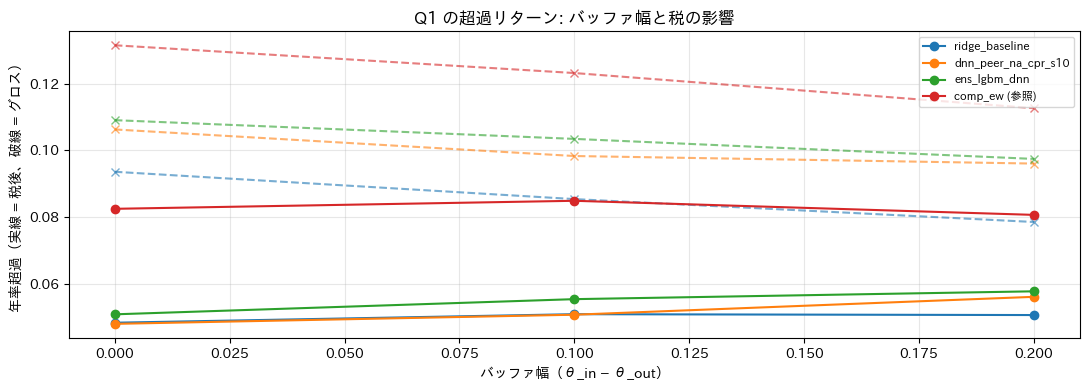

In [7]:
rows = {}
for name, r in results.items():
    for b in BUFFERS:
        s = r.summary[(f"buffer={b:g}", "Q1")]
        rows[(name, b)] = {
            "年率回転率": s["turnover_annual"], "超過 グロス(vs BM)": s["active_return"], "IR グロス": s["information_ratio"],
            "コストドラッグ": s["cost_drag_annual"], "税ドラッグ": s["tax_drag_annual"], "短期比率": s["short_ratio_mean"],
            "超過 税後(vs BM)": s["r_net_active_return"], "IR 税後": s["r_net_information_ratio"], "TE": s["tracking_error"],
        }
tax_tbl = pd.DataFrame(rows).T
tax_tbl.index.names = ["スコア", "バッファ"]
display(tax_tbl.round(3))

fig, ax = plt.subplots(figsize=(11, 4))
for name in CANDIDATES + ["comp_ew (参照)"]:
    ax.plot(BUFFERS, [tax_tbl.loc[(name, b), "超過 税後(vs BM)"] for b in BUFFERS], marker="o", label=name)
    ax.plot(BUFFERS, [tax_tbl.loc[(name, b), "超過 グロス(vs BM)"] for b in BUFFERS], marker="x", linestyle="--", color=ax.lines[-1].get_color(), alpha=0.6)
ax.set_xlabel("バッファ幅（θ_in − θ_out）")
ax.set_ylabel("年率超過（実線 = 税後、破線 = グロス）")
ax.set_title("Q1 の超過リターン: バッファ幅と税の影響")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. まとめ表

候補 3 本と平滑化版、参照を横並びにする。

In [8]:
summary = pd.DataFrame(
    {
        "IC 1m": ic_tbl["IC 1m"], "ICIR 1m": ic_tbl["ICIR 1m"], "t": ic_tbl["t 1m"],
        "Q1 超過 グロス(vs BM)": q_tbl["Q1 超過(vs BM)"], "IR グロス": q_tbl["IR(vs BM)"], "Q1 超過(vs EW)": q_tbl["Q1 超過(vs EW)"],
        "回転率（バッファ 0）": q_tbl["年率回転率"],
        "回転率（バッファ 0.2）": [tax_tbl.loc[(n, 0.2), "年率回転率"] for n in q_tbl.index],
        "税後超過（バッファ 0）": [tax_tbl.loc[(n, 0.0), "超過 税後(vs BM)"] for n in q_tbl.index],
        "税後超過（バッファ 0.2）": [tax_tbl.loc[(n, 0.2), "超過 税後(vs BM)"] for n in q_tbl.index],
        "税後 IR（バッファ 0.2）": [tax_tbl.loc[(n, 0.2), "IR 税後"] for n in q_tbl.index],
    }
)
display(summary.round(3))

,IC 1m,ICIR 1m,t,Q1 超過 グロス(vs BM),IR グロス,Q1 超過(vs EW),回転率（バッファ 0）,回転率（バッファ 0.2）,税後超過（バッファ 0）,税後超過（バッファ 0.2）,税後 IR（バッファ 0.2）
ridge_baseline,0.066,0.444,5.670,0.094,1.216,0.054,3.557,1.620,0.048,0.051,0.683
ridge_baseline_hl1,0.062,0.408,5.204,0.078,1.032,0.038,2.059,1.055,0.046,0.043,0.585
dnn_peer_na_cpr_s10,0.074,0.554,7.074,0.106,1.176,0.066,5.271,2.640,0.048,0.056,0.709
dnn_peer_na_cpr_s10_hl1,0.071,0.498,6.364,0.101,1.190,0.061,3.003,1.511,0.056,0.055,0.694
ens_lgbm_dnn,0.078,0.551,7.038,0.109,1.288,0.069,5.165,2.587,0.051,0.058,0.759
ens_lgbm_dnn_hl1,0.074,0.497,6.340,0.107,1.296,0.067,2.965,1.402,0.062,0.057,0.757
comp_ew (参照),0.056,0.490,6.253,0.132,1.157,0.092,4.049,2.076,0.082,0.081,0.792


## 7. 所見

**IC（india-ai-model 側との整合）**

| | india-ai-model（rank IC） | alphaeval（Spearman、GEMLT `rtn`） | ICIR | t |
| --- | --- | --- | --- | --- |
| ridge_baseline | 0.069 | 0.066 | 0.44 | 5.7 |
| dnn_peer_na_cpr_s10 | 0.078 | 0.074 | 0.55 | 7.1 |
| ens_lgbm_dnn | 0.082 | 0.078 | 0.55 | 7.0 |
| comp_ew（参照） | — | 0.056 | 0.49 | 6.3 |

- リターン定義の違い（mart の `drtn_1m` vs GEMLT 月次 `rtn`）による差は 0.003〜0.004 で、順位・ICIR の構図は同じ。
- 3 本の序列は IC・ICIR とも `ens_lgbm_dnn ≈ dnn_peer_na_cpr_s10 > ridge_baseline`。平滑化（`_hl1`）は IC を 0.003〜0.004 下げ、ICIR を 0.05 程度下げる。
- 3 か月・6 か月の IC は 0.08〜0.095 で 1 か月より高く、12 か月でも 0.05 残る。情報の減衰は遅い（平滑化・バッファが効く余地）。
- 年別では 2020 年が全モデルで低く（0.01〜0.03）、2026 年（6 か月）は負。`comp_ew` は 2021〜2023 年に AI モデルを上回る年がある。

**Q1（最上位 20%、等ウェイト）のロングオンリー超過（対 MSCI India）**

| | Q1 超過 グロス | IR | 対 EW 参照 | Q1−Q5 | 年率回転率 |
| --- | --- | --- | --- | --- | --- |
| ridge_baseline | 9.4% | 1.22 | 5.4% | 13.0% | 356% |
| dnn_peer_na_cpr_s10 | 10.6% | 1.18 | 6.6% | 16.0% | 527% |
| ens_lgbm_dnn | 10.9% | 1.29 | 6.9% | 16.1% | 517% |
| comp_ew（参照） | 13.2% | 1.16 | 9.2% | 17.7% | 405% |

- Q1→Q5 はすべて単調。AI モデルは Q5（最下位）が 3.7〜5.0% と低く、Q1−Q5 スプレッドは `comp_ew` に近い。
- しかし **ロングオンリーの Q1 超過では `comp_ew` が AI モデルを上回る**（13.2% vs 10.9%、対 EW 参照でも 9.2% vs 6.9%）。
  AI モデルは IC（全体の順位）は高いが、最上位 20% に集中する超過は合成スコアより小さい。
  AI モデルの情報は下位（ショート側）にも分散しており、ロングオンリーでは使い切れない。
- 回転率は AI モデルが 517〜527%（`ridge` 356%）と高く、`comp_ew`（405%）を上回る。
- 時価総額ウェイト（上限 5%）では超過が 4〜5.5 ポイント減衰し、`ens_lgbm_dnn` の CW 超過は 5.4%（`comp_ew` 9.6%）。
  AI モデルの方が小型株への依存がやや大きい。

**税控除後（信託扱い税率、INR 建て、売買コスト 15/25bp、バーンイン 12 か月）**

| | バッファ 0: 回転率 / 税後超過 | バッファ 0.2: 回転率 / 税後超過 / 税後 IR |
| --- | --- | --- |
| ridge_baseline | 356% / 4.8% | 162% / 5.1% / 0.68 |
| dnn_peer_na_cpr_s10 | 527% / 4.8% | 264% / 5.6% / 0.71 |
| ens_lgbm_dnn | 517% / 5.1% | 259% / 5.8% / 0.76 |
| ens_lgbm_dnn_hl1 | 297% / 6.2% | 140% / 5.7% / 0.76 |
| comp_ew（参照） | 405% / 8.2% | 208% / 8.1% / 0.79 |

- バッファなしでは税ドラッグ 4.3%、コスト 2.6% で、AI モデルの税後超過は 5% 前後まで落ちる（グロス 10.9% の半分弱）。
  短期比率は 93% と、ほぼすべての実現益が STCG。
- 平滑化（`_hl1`）とバッファ 0.2 はどちらも回転率を半減させ、税後超過を 0.7〜1.1 ポイント改善する。両方を併用すると
  回転率 140% まで下がるが、グロスの減少（10.7% → 8.5%）が税の節約を上回り、税後では単独適用と同程度（5.7%）。
  **平滑化かバッファのどちらか一方で十分**で、両方は過剰。
- 税後でも `comp_ew` が 8% 台で AI モデルを 2〜3 ポイント上回る。IC の優位がロングオンリー・税後の超過に結びついていない。

**判断**

1. 3 本の中では `ens_lgbm_dnn` が IC・Q1 超過・税後 IR のいずれでも最良。`ridge_baseline` からの改善は Q1 超過で +1.5 ポイント、税後で +0.3〜0.7 ポイント。
2. ただし現状の AI モデルは、ロングオンリー・税後の評価軸では合成スコア `comp_ew` に届かない。
   原因は (a) 情報が上位 20% に集中しておらず下位側に分散していること、(b) 回転率が高いこと。
3. 改善の方向: (a) 学習目的をロングオンリー向けに寄せる（上位分位の精度、または `comp_ew` との合成）、
   (b) 回転率を学習時に制御する（長期ターゲット、平滑化の半減期を伸ばす）、(c) `comp_ew` とのアンサンブルで
   両者の情報の違い（IC は AI、上位集中は composite）を取り込む。(c) は既存スコアだけで試せるので次に行う。